In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
df = pd.read_csv('data/results/spectra_by_frequency_network_acompcor.csv',low_memory=False)
df = df[df['frequency']==0.1]
df = df[df['network']=='Default']
# remove nan rows from PPL  
df = df.dropna(subset=['PPL_mcg/L'])
df.columns

Index(['subject', 'session', 'task', 'run', 'age', 'sex', 'drug_admin_time',
       'ppl_time', 'sdi_time', 'scan_start_time', 'scan_end_time',
       'scan_min_since_admin', 'ppl_min_since_admin', 'sdi_min_since_admin',
       'ppl_min_since_scan', 'sdi_min_since_scan', 'PPL_mcg/L', 'SDI',
       'time_interval', 'tr', 'te', 'num_vols', 'ped', 'coil_name',
       'coil_active', 'scanner', 'include_scan_coil_numvols',
       'include_manual_qc', 'ratio_outliers_fd0.5_std_dvars1000', 'mean_fd',
       'mean_std_dvars', 'max_fd', 'outlier_locs', 'scan_filename',
       'preproc_filename_volumetric', 'preproc_filename_cifti',
       'preproc_filename_cifti_despiked', 'preproc_filename_cifti_aroma',
       'strategy', 'network', 'frequency', 'log_power', 'partial_residuals',
       'partial_residuals_nomotion'],
      dtype='object')

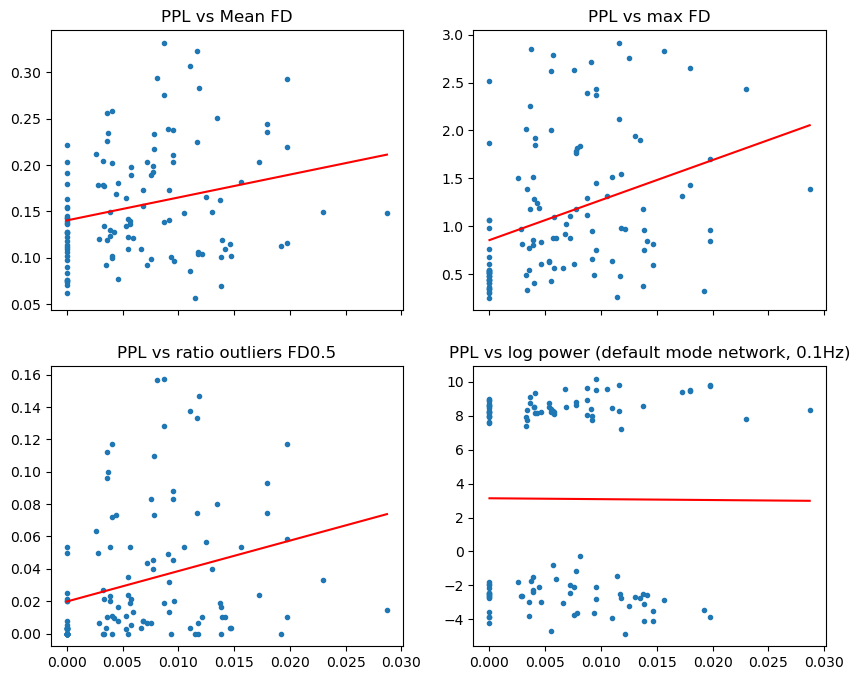

In [20]:
fig,axs = plt.subplots(2,2,figsize=(10,8),sharex=True)
axs[0,0].plot(df['PPL_mcg/L'],df['mean_fd'],'.')
axs[0,0].set_title('PPL vs Mean FD')
# add linear fit
b = np.polyfit(df['PPL_mcg/L'],df['mean_fd'],1)
x = np.array([df['PPL_mcg/L'].min(),df['PPL_mcg/L'].max()])
y = b[0]*x + b[1]
axs[0,0].plot(x,y,'r-')

axs[0,1].plot(df['PPL_mcg/L'],df['max_fd'],'.')
axs[0,1].set_title('PPL vs max FD')
b = np.polyfit(df['PPL_mcg/L'],df['max_fd'],1)
x = np.array([df['PPL_mcg/L'].min(),df['PPL_mcg/L'].max()])
y = b[0]*x + b[1]
axs[0,1].plot(x,y,'r-')

axs[1,0].plot(df['PPL_mcg/L'],df['ratio_outliers_fd0.5_std_dvars1000'],'.')
axs[1,0].set_title('PPL vs ratio outliers FD0.5')
b = np.polyfit(df['PPL_mcg/L'],df['ratio_outliers_fd0.5_std_dvars1000'],1)
x = np.array([df['PPL_mcg/L'].min(),df['PPL_mcg/L'].max()])
y = b[0]*x + b[1]
axs[1,0].plot(x,y,'r-')

axs[1,1].plot(df['PPL_mcg/L'],df['log_power'],'.')
axs[1,1].set_title('PPL vs log power (default mode network, 0.1Hz)')
b = np.polyfit(df['PPL_mcg/L'],df['log_power'],1)
x = np.array([df['PPL_mcg/L'].min(),df['PPL_mcg/L'].max()])
y = b[0]*x + b[1]
axs[1,1].plot(x,y,'r-')

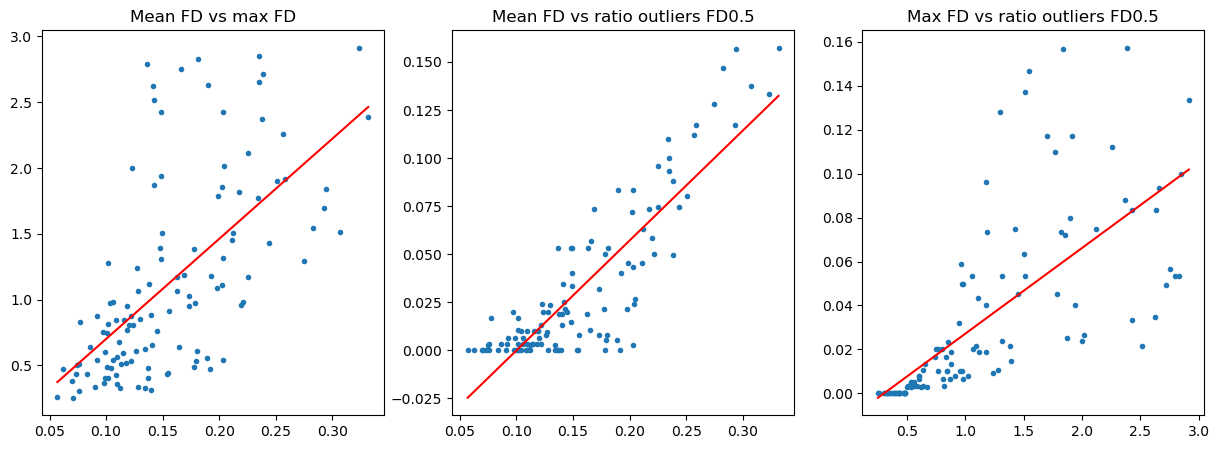

In [23]:
# do the same but between the three motion metrics
fig,axs = plt.subplots(1,3,figsize=(15,5))
axs[0].plot(df['mean_fd'],df['max_fd'],'.')
axs[0].set_title('Mean FD vs max FD')
b = np.polyfit(df['mean_fd'],df['max_fd'],1)
x = np.array([df['mean_fd'].min(),df['mean_fd'].max()])
y = b[0]*x + b[1]
axs[0].plot(x,y,'r-')

axs[1].plot(df['mean_fd'],df['ratio_outliers_fd0.5_std_dvars1000'],'.')
axs[1].set_title('Mean FD vs ratio outliers FD0.5')
b = np.polyfit(df['mean_fd'],df['ratio_outliers_fd0.5_std_dvars1000'],1)
x = np.array([df['mean_fd'].min(),df['mean_fd'].max()])
y = b[0]*x + b[1]
axs[1].plot(x,y,'r-')

axs[2].plot(df['max_fd'],df['ratio_outliers_fd0.5_std_dvars1000'],'.')
axs[2].set_title('Max FD vs ratio outliers FD0.5')
b = np.polyfit(df['max_fd'],df['ratio_outliers_fd0.5_std_dvars1000'],1)
x = np.array([df['max_fd'].min(),df['max_fd'].max()])
y = b[0]*x + b[1]
axs[2].plot(x,y,'r-')

Visualize "synthetic" motion and corresponding spectra by adding stuff to time-series from one scan

In [233]:
sub = 'sub-53888'
run = 'run-3'
acq = 'acq-ep2d'
V = np.loadtxt('data/denoised/high-pass-only/'+sub+'/ses-PSI/func/'+sub+'_ses-PSI_task-rest_'+acq+'_dir-AP_'+run+'_space-fsLR_den-91k_bold_denoised_parcellated_schaefertian232.txt')
spectrum = np.loadtxt('data/spectra/high-pass-only/'+sub+'/ses-PSI/func/'+sub+'_ses-PSI_task-rest_'+acq+'_dir-AP_'+run+'_space-fsLR_den-91k_bold_mtspectra_parcellated_schaefertian232.txt')
motion_ts = np.loadtxt('data/spectra/motion/'+sub+'/ses-PSI/func/'+sub+'_ses-PSI_task-rest_'+acq+'_dir-AP_'+run+'_space-fsLR_den-91k_bold_motion.txt')
motion_spectrum = np.loadtxt('data/spectra/motion/'+sub+'/ses-PSI/func/'+sub+'_ses-PSI_task-rest_'+acq+'_dir-AP_'+run+'_space-fsLR_den-91k_bold_motion_mtspectra.txt')
f = np.loadtxt('data/frequencies_MR45.txt')

In [234]:
voxel = 40

Text(0.5, 1.0, 'Parcellated Time Series')

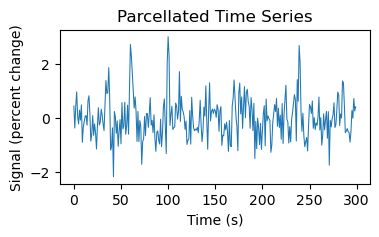

In [235]:
plt.figure(figsize=(4,2))
plt.plot(V[:,voxel], linewidth=0.75)
plt.xlabel('Time (s)')
plt.ylabel('Signal (percent change)')
plt.title('Parcellated Time Series')

Text(0.5, 1.0, 'Parcel spectrum')

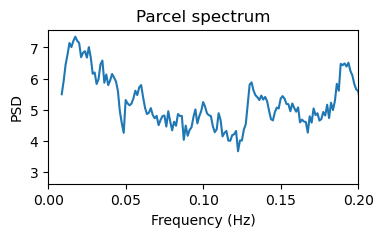

In [236]:
plt.figure(figsize=(4,2))
plt.plot(f[f>0.008], spectrum[f>0.008,voxel])
plt.xlim(0,0.2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Parcel spectrum')

Text(0.5, 1.0, 'Denoised Motion Time Series')

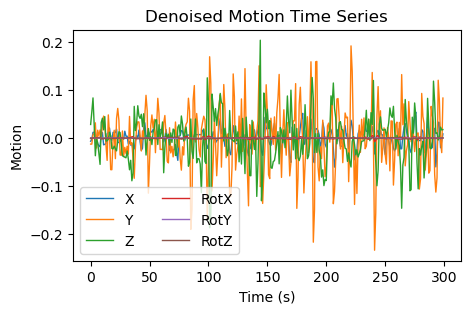

In [237]:
plt.figure(figsize=(5,3))
plt.plot(motion_ts.T, linewidth=1)
plt.legend(['X','Y','Z','RotX','RotY','RotZ'],ncol=2)
plt.xlabel('Time (s)')
plt.ylabel('Motion')
plt.title('Denoised Motion Time Series')

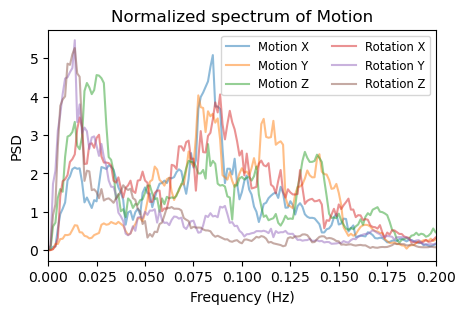

In [238]:
plt.figure(figsize=(5,3))
plt.plot(f, motion_spectrum/np.std(motion_spectrum,axis=0), alpha=0.5)
plt.xlim(0,0.2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Normalized spectrum of Motion')
plt.legend(['Motion X','Motion Y','Motion Z','Rotation X','Rotation Y','Rotation Z'], loc='upper right', fontsize='small', ncol=2)

In [239]:
var_mt

array([[ 0.34024251, 10.80695584,  0.68308846, ..., 12.91287152,
        12.03131255,  9.81399131],
       [ 0.69779137,  1.06211327,  0.70941886, ...,  6.23777305,
         0.80661246,  0.82480908],
       [ 0.15650049,  0.20746573,  0.16226623, ...,  0.35081756,
         0.1600935 ,  0.16770308],
       ...,
       [ 0.06652869,  0.21283586,  0.03506003, ...,  0.10662116,
         0.08052697,  0.07286304],
       [ 0.20110917,  0.33303095,  0.1264393 , ...,  0.04848465,
         0.1786973 ,  0.03336702],
       [ 0.35964864,  0.32252877,  0.7066766 , ...,  0.16755321,
         1.84592577,  0.12770555]], shape=(201, 232))

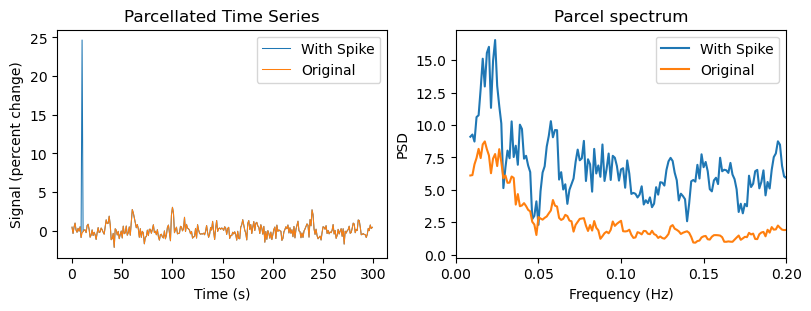

In [240]:
# make a side-by-side visualization of the parcle time series and spectrum vs the same with an added transient spike
spike_time = 10
V_spike = V.copy()
V_spike[spike_time:spike_time+1, voxel] += 25
import nitime.algorithms as tsa

f, psd_mt, _ = tsa.spectral.multi_taper_psd(V.T, #assumes data is space x time
                                            Fs=1/2,
                                            NW=None, # defaults to 4, which means 8 tapers
                                            BW=None, # defaults to None
                                            adaptive=False, # adaptive weighting of tapers, could be used (slow)
                                            jackknife=False, # jackknife estimation of variance, which we don't assess
                                            low_bias=True, # Only use tapers with low bias, which is the default
                                            sides='default', #always onesided for non-complex-valued data
                                            NFFT=400)

f, psd_mt_spike, _ = tsa.spectral.multi_taper_psd(V_spike.T, #assumes data is space x time
                                            Fs=1/2,
                                            NW=None, # defaults to 4, which means 8 tapers
                                            BW=None, # defaults to None
                                            adaptive=False, # adaptive weighting of tapers, could be used (slow)
                                            jackknife=False, # jackknife estimation of variance, which we don't assess
                                            low_bias=True, # Only use tapers with low bias, which is the default
                                            sides='default', #always onesided for non-complex-valued data
                                            NFFT=400)
psd_mt_spike = psd_mt_spike.T  # transpose to get time x space
psd_mt = psd_mt.T  # transpose to get time x space
plt.figure(figsize=(8,3),layout='constrained')
plt.subplot(1,2,1)
plt.plot(V_spike[:,voxel], linewidth=0.75, label='With Spike')
plt.plot(V[:,voxel], linewidth=0.75, label='Original')
plt.xlabel('Time (s)')
plt.ylabel('Signal (percent change)')
plt.title('Parcellated Time Series')
plt.legend()
plt.subplot(1,2,2)
plt.plot(f[f>0.008], psd_mt_spike[f>0.008,voxel], label='With Spike')
plt.plot(f[f>0.008], psd_mt[f>0.008,voxel], label='Original')
plt.xlim(0,0.2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Parcel spectrum')
plt.legend()

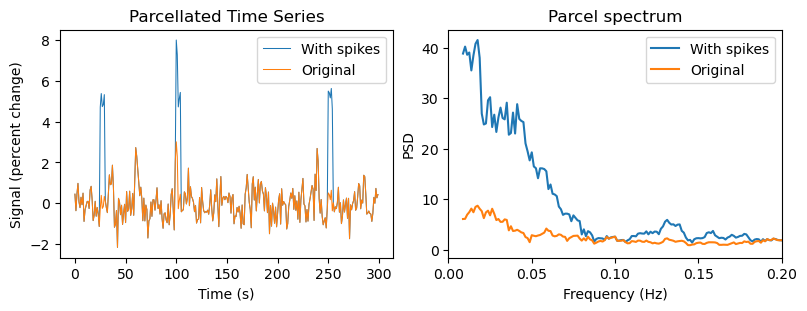

In [241]:
# make a side-by-side visualization of the parcle time series and spectrum vs the same with an added transient spike
spike_times = [25, 100, 250]
V_spike = V.copy()
for spike_time in spike_times:
    V_spike[spike_time:spike_time+5, voxel] += 5
import nitime.algorithms as tsa

f, psd_mt, _ = tsa.spectral.multi_taper_psd(V.T, #assumes data is space x time
                                            Fs=1/2,
                                            NW=None, # defaults to 4, which means 8 tapers
                                            BW=None, # defaults to None
                                            adaptive=False, # adaptive weighting of tapers, could be used (slow)
                                            jackknife=False, # jackknife estimation of variance, which we don't assess
                                            low_bias=True, # Only use tapers with low bias, which is the default
                                            sides='default', #always onesided for non-complex-valued data
                                            NFFT=400)

f, psd_mt_spike, _ = tsa.spectral.multi_taper_psd(V_spike.T, #assumes data is space x time
                                            Fs=1/2,
                                            NW=None, # defaults to 4, which means 8 tapers
                                            BW=None, # defaults to None
                                            adaptive=False, # adaptive weighting of tapers, could be used (slow)
                                            jackknife=False, # jackknife estimation of variance, which we don't assess
                                            low_bias=True, # Only use tapers with low bias, which is the default
                                            sides='default', #always onesided for non-complex-valued data
                                            NFFT=400)
psd_mt_spike = psd_mt_spike.T  # transpose to get time x space
psd_mt = psd_mt.T  # transpose to get time x space
plt.figure(figsize=(8,3),layout='constrained')
plt.subplot(1,2,1)
plt.plot(V_spike[:,voxel], linewidth=0.75, label='With spikes')
plt.plot(V[:,voxel], linewidth=0.75, label='Original')
plt.xlabel('Time (s)')
plt.ylabel('Signal (percent change)')
plt.title('Parcellated Time Series')
plt.legend()
plt.subplot(1,2,2)
plt.plot(f[f>0.008], psd_mt_spike[f>0.008,voxel], label='With spikes')
plt.plot(f[f>0.008], psd_mt[f>0.008,voxel], label='Original')
plt.xlim(0,0.2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Parcel spectrum')
plt.legend()

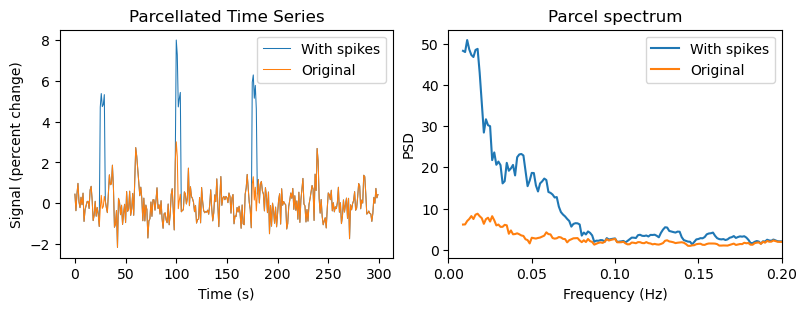

In [244]:
# make a side-by-side visualization of the parcle time series and spectrum vs the same with an added transient spike
spike_times = [25, 100, 175]
V_spike = V.copy()
for spike_time in spike_times:
    V_spike[spike_time:spike_time+5, voxel] += 5
import nitime.algorithms as tsa

f, psd_mt, _ = tsa.spectral.multi_taper_psd(V.T, #assumes data is space x time
                                            Fs=1/2,
                                            NW=None, # defaults to 4, which means 8 tapers
                                            BW=None, # defaults to None
                                            adaptive=False, # adaptive weighting of tapers, could be used (slow)
                                            jackknife=False, # jackknife estimation of variance, which we don't assess
                                            low_bias=True, # Only use tapers with low bias, which is the default
                                            sides='default', #always onesided for non-complex-valued data
                                            NFFT=400)

f, psd_mt_spike, _ = tsa.spectral.multi_taper_psd(V_spike.T, #assumes data is space x time
                                            Fs=1/2,
                                            NW=None, # defaults to 4, which means 8 tapers
                                            BW=None, # defaults to None
                                            adaptive=False, # adaptive weighting of tapers, could be used (slow)
                                            jackknife=False, # jackknife estimation of variance, which we don't assess
                                            low_bias=True, # Only use tapers with low bias, which is the default
                                            sides='default', #always onesided for non-complex-valued data
                                            NFFT=400)
psd_mt_spike = psd_mt_spike.T  # transpose to get time x space
psd_mt = psd_mt.T  # transpose to get time x space
plt.figure(figsize=(8,3),layout='constrained')
plt.subplot(1,2,1)
plt.plot(V_spike[:,voxel], linewidth=0.75, label='With spikes')
plt.plot(V[:,voxel], linewidth=0.75, label='Original')
plt.xlabel('Time (s)')
plt.ylabel('Signal (percent change)')
plt.title('Parcellated Time Series')
plt.legend()
plt.subplot(1,2,2)
plt.plot(f[f>0.008], psd_mt_spike[f>0.008,voxel], label='With spikes')
plt.plot(f[f>0.008], psd_mt[f>0.008,voxel], label='Original')
plt.xlim(0,0.2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Parcel spectrum')
plt.legend()

In [242]:
def compute_fd(motion_params, radius=50, degrees=False):
    """
    Compute framewise displacement (Power et al., 2012).
    
    motion_params: np.ndarray of shape (T, 6)
                   columns = [x, y, z, pitch, roll, yaw]
    radius: head radius in mm
    degrees: whether rotations are in degrees
    """
    diff = np.abs(np.diff(motion_params, axis=0))
    if degrees:
        diff[:, 3:] = np.deg2rad(diff[:, 3:])
    diff[:, 3:] *= radius  # convert rotations to mm
    fd = np.sum(diff, axis=1)
    return np.insert(fd, 0, 0)  # prepend 0 for the first frame

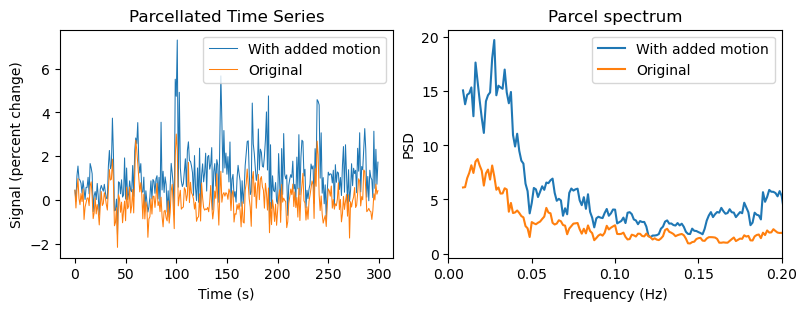

In [243]:
# compute framewise displacement from translation and rotation
V_spike = V.copy()
fd = compute_fd(motion_ts.T, radius=50, degrees=True)
V_spike += 10*fd[:, np.newaxis]

f, psd_mt, _ = tsa.spectral.multi_taper_psd(V.T-np.mean(V.T,1)[:,None], #assumes data is space x time
                                            Fs=1/2,
                                            NW=None, # defaults to 4, which means 8 tapers
                                            BW=None, # defaults to None
                                            adaptive=False, # adaptive weighting of tapers, could be used (slow)
                                            jackknife=False, # jackknife estimation of variance, which we don't assess
                                            low_bias=True, # Only use tapers with low bias, which is the default
                                            sides='default', #always onesided for non-complex-valued data
                                            NFFT=400)

f, psd_mt_spike, _ = tsa.spectral.multi_taper_psd(V_spike.T-np.mean(V_spike.T,1)[:,None], #assumes data is space x time
                                            Fs=1/2,
                                            NW=None, # defaults to 4, which means 8 tapers
                                            BW=None, # defaults to None
                                            adaptive=False, # adaptive weighting of tapers, could be used (slow)
                                            jackknife=False, # jackknife estimation of variance, which we don't assess
                                            low_bias=True, # Only use tapers with low bias, which is the default
                                            sides='default', #always onesided for non-complex-valued data
                                            NFFT=400)
psd_mt_spike = psd_mt_spike.T  # transpose to get time x space
psd_mt = psd_mt.T  # transpose to get time x space
plt.figure(figsize=(8,3),layout='constrained')
plt.subplot(1,2,1)
plt.plot(V_spike[:,voxel], linewidth=0.75, label='With added motion')
plt.plot(V[:,voxel], linewidth=0.75, label='Original')
plt.xlabel('Time (s)')
plt.ylabel('Signal (percent change)')
plt.title('Parcellated Time Series')
plt.legend()
plt.subplot(1,2,2)
plt.plot(f[f>0.008], psd_mt_spike[f>0.008,voxel], label='With added motion')
plt.plot(f[f>0.008], psd_mt[f>0.008,voxel], label='Original')
plt.xlim(0,0.2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Parcel spectrum')
plt.legend()